# VAE UI Pipeline Notebook

This notebook is the quickest way to run the new 3-image pipeline end to end:

`3 images -> OpenAI semantic controls -> PC vector -> local frozen VAE decode -> wav + waveform`

It supports both:

- launching the interactive Gradio UI inside the notebook
- running one direct reconstruction call from three image file paths


In [11]:
from IPython.display import Markdown, display
from pathlib import Path
import json
import os
import subprocess
import sys

try:
    from google.colab import drive, userdata  # type: ignore
    IN_COLAB = True
except Exception:
    userdata = None
    IN_COLAB = False


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'run_llm_to_haptic.py').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the thesis project root from the current notebook location.')


REPO_URL = 'https://github.com/cindy-77jiayi/thesis_hapticAE.git'
BRANCH = 'vae-ui-pipeline'
FORCE_CLEAN_CLONE = False
INSTALL_REQUIREMENTS = True

if IN_COLAB:
    display(Markdown('### Optional Google Drive mount'))
    try:
        drive.mount('/content/drive')
    except Exception as exc:
        print('Drive mount skipped:', exc)

    PROJECT_ROOT = Path('/content/thesis_hapticAE')
    if FORCE_CLEAN_CLONE and PROJECT_ROOT.exists():
        subprocess.run(['rm', '-rf', str(PROJECT_ROOT)], check=True)

    if not (PROJECT_ROOT / '.git').exists():
        subprocess.run(['git', 'clone', '--branch', BRANCH, '--single-branch', REPO_URL, str(PROJECT_ROOT)], check=True)
    else:
        subprocess.run(['git', '-C', str(PROJECT_ROOT), 'fetch', '--all'], check=False)
        subprocess.run(['git', '-C', str(PROJECT_ROOT), 'checkout', BRANCH], check=True)
        subprocess.run(['git', '-C', str(PROJECT_ROOT), 'pull', '--ff-only', 'origin', BRANCH], check=False)

    try:
        os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
        print('Loaded OPENAI_API_KEY from Colab secrets.')
    except Exception as exc:
        print('OPENAI_API_KEY was not loaded from Colab secrets:', exc)
else:
    PROJECT_ROOT = find_project_root(Path.cwd().resolve())

if INSTALL_REQUIREMENTS:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(PROJECT_ROOT / 'requirements.txt')], check=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('IN_COLAB =', IN_COLAB)
print('OPENAI_API_KEY loaded =', bool(os.getenv('OPENAI_API_KEY')))


### Optional Google Drive mount

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded OPENAI_API_KEY from Colab secrets.
PROJECT_ROOT = /content/thesis_hapticAE
IN_COLAB = True
OPENAI_API_KEY loaded = True


In [16]:
from src.pipelines.semantic_reconstruction import load_frozen_model_spec, run_three_image_reconstruction
from src.ui import build_demo

GOOGLE_DRIVE_FROZEN_MANIFEST = Path('/content/drive/MyDrive/thesis/frozen_model_outputs/latest_frozen_manifest.json')
FROZEN_MANIFEST_PATH = GOOGLE_DRIVE_FROZEN_MANIFEST
if not FROZEN_MANIFEST_PATH.exists():
    candidate_paths = [
        PROJECT_ROOT / 'outputs' / 'latest_frozen_manifest.json',
        PROJECT_ROOT / 'outputs' / 'vae_balanced' / 'frozen_manifest.json',
        PROJECT_ROOT / 'colab' / 'latest_frozen_manifest.json',
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            FROZEN_MANIFEST_PATH = candidate
            break

OPENAI_MODEL = 'gpt-4.1-mini'
UI_OUTPUTS_DIR = PROJECT_ROOT / 'outputs' / 'vae_llm_ui_notebook'
SHARE_UI = False
UI_SERVER_NAME = '127.0.0.1'
UI_SERVER_PORT = 8800

print('Google Drive manifest:', GOOGLE_DRIVE_FROZEN_MANIFEST)
print('Frozen manifest candidate:', FROZEN_MANIFEST_PATH)
print('UI output root:', UI_OUTPUTS_DIR)


Google Drive manifest: /content/drive/MyDrive/thesis/frozen_model_outputs/latest_frozen_manifest.json
Frozen manifest candidate: /content/drive/MyDrive/thesis/frozen_model_outputs/latest_frozen_manifest.json
UI output root: /content/thesis_hapticAE/outputs/vae_llm_ui_notebook


In [17]:
if not FROZEN_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        'Frozen manifest not found. It should usually live at /content/drive/MyDrive/thesis/frozen_model_outputs/latest_frozen_manifest.json. Update FROZEN_MANIFEST_PATH in the previous cell if your bundle lives elsewhere.'
    )

spec = load_frozen_model_spec(FROZEN_MANIFEST_PATH)
print('Resolved frozen manifest:', spec.manifest_path)
print('Run name:', spec.run_name)
print('Config path:', spec.config_path)
print('Checkpoint path:', spec.checkpoint_path)
print('PCA dir:', spec.pca_dir)
print('Sample rate:', spec.target_sr)
print('Signal length:', spec.target_len)


Resolved frozen manifest: /content/drive/MyDrive/thesis/frozen_model_outputs/latest_frozen_manifest.json
Run name: vae_balanced
Config path: /content/drive/MyDrive/thesis/frozen_model_outputs/vae_balanced/config.yaml
Checkpoint path: /content/drive/MyDrive/thesis/frozen_model_outputs/vae_balanced/best_model.pt
PCA dir: /content/drive/MyDrive/thesis/frozen_model_outputs/vae_balanced/pca
Sample rate: 8000
Signal length: 4000


## Launch The Interactive UI

Run the next cell to open the same 3-image UI used by `launch_vae_ui.py`.

If you are in Colab, set `SHARE_UI = True` above if you want a public link.


In [18]:
demo = build_demo(
    frozen_manifest=str(FROZEN_MANIFEST_PATH),
    model=OPENAI_MODEL,
    outputs_dir=str(UI_OUTPUTS_DIR),
)
demo.launch(
    server_name=UI_SERVER_NAME,
    server_port=UI_SERVER_PORT,
    share=SHARE_UI,
    prevent_thread_lock=True,
    inline=True,
    allowed_paths=[str(UI_OUTPUTS_DIR)],
)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## Direct One-Shot Run Without The UI

Set three file paths below if you want to run one reconstruction call directly from the notebook.
This is useful for debugging prompt / output artifacts quickly.


In [19]:
IMAGE_PATHS = [
    '/content/Chime iOS 59.png',
    '/content/Chime iOS 60.png',
    '/content/Chime iOS 61.png',
]
NOTES = ''
DIRECT_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'vae_llm_notebook_direct'


Run dir: /content/thesis_hapticAE/outputs/vae_llm_notebook_direct
Generated wav: /content/thesis_hapticAE/outputs/vae_llm_notebook_direct/generated.wav
Waveform image: /content/thesis_hapticAE/outputs/vae_llm_notebook_direct/waveform.png
Semantic controls:
{
  "frequency": 0.3,
  "intensity": 0.4,
  "envelope_modulation": 0.1,
  "temporal_grouping": 0.0,
  "sharpness": 0.2
}
Rationale:
{
  "frequency": "steady UI interaction related vibrations usually have low frequency.",
  "intensity": "moderate intensity to indicate confirmation and input feedback.",
  "envelope_modulation": "mostly continuous with slight modulation during user actions.",
  "temporal_grouping": "no strong rhythmic pattern observed; smooth transitions between screens.",
  "sharpness": "mild sharpness reflecting soft clicks and taps in UI."
}
PC vector:
[
  -1.6069200038909912,
  -0.17389999330043793,
  -2.0215299129486084,
  -1.620300054550171,
  -1.1775599718093872,
  0.0,
  0.0,
  0.0
]


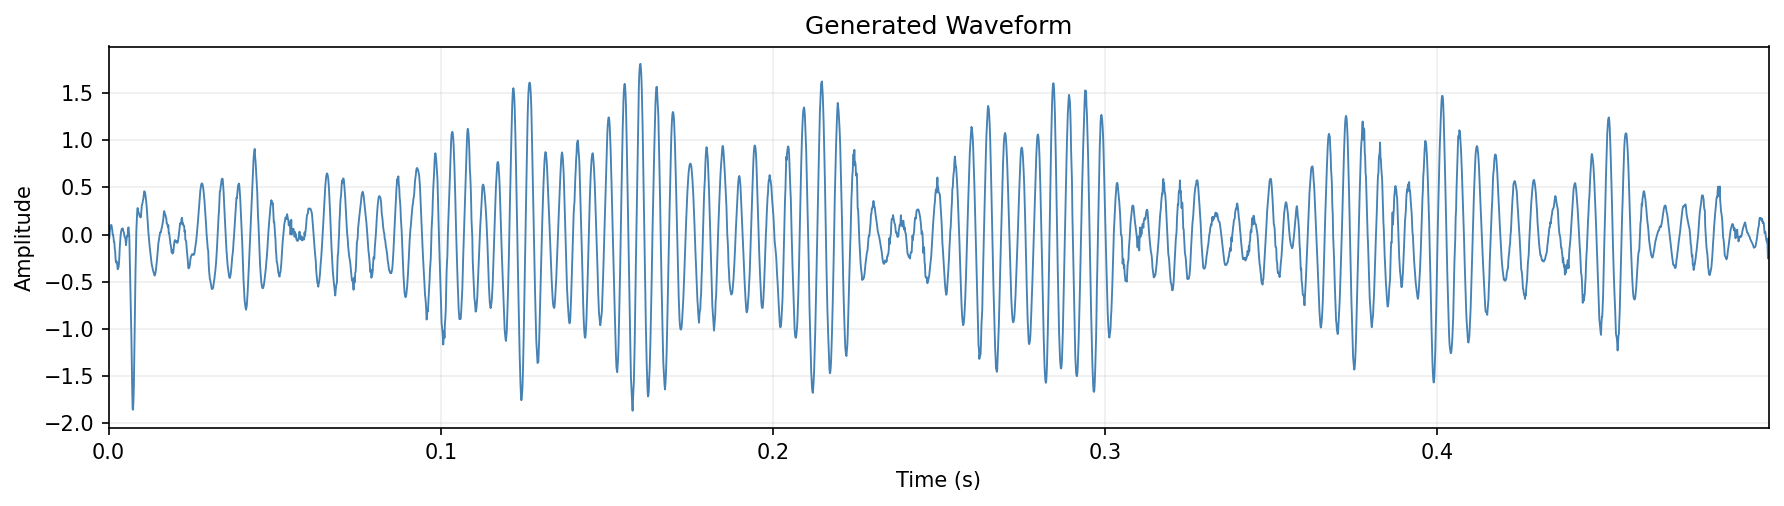

In [20]:
from IPython.display import Audio, Image, display

cleaned_paths = [path for path in IMAGE_PATHS if str(path).strip()]
if len(cleaned_paths) != 3:
    raise ValueError('Please set exactly 3 image paths in IMAGE_PATHS before running this cell.')

result = run_three_image_reconstruction(
    image_paths=cleaned_paths,
    notes=NOTES,
    run_dir=DIRECT_OUTPUT_DIR,
    frozen_manifest_path=FROZEN_MANIFEST_PATH,
    model=OPENAI_MODEL,
)

print('Run dir:', result['run_dir'])
print('Generated wav:', result['generated_wav'])
print('Waveform image:', result['waveform_image'])
print('Semantic controls:')
print(json.dumps(result['segments'][0]['semantic_controls'], indent=2, ensure_ascii=False))
print('Rationale:')
print(json.dumps(result['segments'][0]['rationale'], indent=2, ensure_ascii=False))
print('PC vector:')
print(json.dumps(result['segments'][0]['pc_vector'], indent=2, ensure_ascii=False))

display(Audio(filename=result['generated_wav']))
display(Image(filename=result['waveform_image']))


## Inspect The Latest Run Artifacts

This helps you quickly view the files written by the UI or the direct call.


In [ ]:
from pprint import pprint

run_roots = [
    UI_OUTPUTS_DIR,
    DIRECT_OUTPUT_DIR,
]

latest_run = None
for root in run_roots:
    if root.exists():
        candidates = sorted([path for path in root.iterdir() if path.is_dir()])
        if candidates:
            latest_run = candidates[-1]

if latest_run is None:
    print('No run directories found yet.')
else:
    print('Latest run:', latest_run)
    for path in sorted(latest_run.rglob('*')):
        if path.is_file():
            print(path.relative_to(latest_run))

    metadata_path = latest_run / 'run_metadata.json'
    if metadata_path.exists():
        print('
run_metadata.json')
        pprint(json.loads(metadata_path.read_text(encoding='utf-8')))
